# Fair Lending Project - Seattle University


Data Modeling - Combine Datasets (SBA,FRED, CENSUS) for analytics

In [50]:
import pandas as pd
import numpy as np
import sqlite3
import os
import requests
import matplotlib.pyplot as plt
import seaborn as sns




## Environment Setup

In [ ]:
os.makedirs('../data', exist_ok=True)

sba_project_db_path = '../data/sba_loans.db'
sba_loan_db_url = 'https://www.dropbox.com/scl/fi/wbv3d7rekx9l638y18nxq/sba_loans.db?rlkey=n66u91ete4q6jdwfnm8fuis48&st=kvf78bsm&dl=1'

db_fred_path = '../data/fred_indicators.db'
db_census_path = '../data/sba_census.db'

db_census_url = 'https://www.dropbox.com/scl/fi/n3kq9j0cmncf05l1r8y12/sba_census.db?rlkey=1weab5lkylssqnb71xb47tlay&dl=1'
db_fred_url = 'https://www.dropbox.com/scl/fi/73whajs6vtycejpjut8s9/fred_indicators.db?rlkey=2x1caljfbt7h60b9nai8x14vq&dl=1'


#Cache data locally if not already present
if not os.path.exists(sba_project_db_path):
    print("Downloading sba_loans.db ...")
    response = requests.get(sba_loan_db_url)
    response.raise_for_status()
    with open(sba_project_db_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded sba_loans.db.")
else:
    print("sba_loans.db already exists.")
if not os.path.exists(db_fred_path):
    print("Downloading fred_indicators.db ...")
    response = requests.get(db_fred_url)
    response.raise_for_status()
    with open(db_fred_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded fred_indicators.db")
else:
    print("fred_indicators.db already exists.")

if not os.path.exists(db_census_path):
    print("Downloading sba_census.db ...")
    response = requests.get(db_census_url)
    response.raise_for_status()
    with open(db_census_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded sba_census.db.")
else:
    print("sba_census.db already exists.")

sba_loans.db already exists.
fred_indicators.db already exists.
sba_census.db already exists.


## Load Data

In [52]:
conn = sqlite3.connect(sba_project_db_path)
df_sba_loan = pd.read_sql_query("SELECT * FROM V_SBA_LOAN", conn)
conn.close()

print(f"Loaded {len(df_sba_loan)} loans data from the SQL View.")

Loaded 886649 loans data from the SQL View.


In [53]:
df_sba_loan.head()

,loan_id,naics_2digit,state,approval_year,term,no_emp,new_exist,urban_rural,rev_line_cr,low_doc,gross_approved,sba_approved,disbursement_gross,is_default,sector_text
0,1000014003,45,IN,1997,84,4,2.0,0,N,Y,60000.0,48000.0,60000.0,0,44-45
1,1000024006,72,IN,1997,60,2,2.0,0,N,Y,40000.0,32000.0,40000.0,0,72
2,1000034009,62,IN,1997,180,7,1.0,0,N,N,287000.0,215250.0,287000.0,0,62
3,1000044001,0,OK,1997,60,2,1.0,0,N,Y,35000.0,28000.0,35000.0,0,99
4,1000054004,0,FL,1997,240,14,1.0,0,N,N,229000.0,229000.0,229000.0,0,99


In [54]:
df_sba_loan.describe(include='all')

,loan_id,naics_2digit,state,approval_year,term,no_emp,new_exist,urban_rural,rev_line_cr,low_doc,gross_approved,sba_approved,disbursement_gross,is_default,sector_text
count,8.866490e+05,886649,886637,886649.000000,886649.000000,886649.000000,885505.000000,886649.000000,609394,880650,8.866490e+05,8.866490e+05,8.866490e+05,886649.000000,886649
unique,NaN,25,51,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,21
top,NaN,0,CA,NaN,NaN,NaN,NaN,NaN,N,N,NaN,NaN,NaN,NaN,99
freq,NaN,191150,129355,NaN,NaN,NaN,NaN,NaN,408763,770479,NaN,NaN,NaN,NaN,191150
mean,4.800955e+09,NaN,NaN,2001.351242,110.093821,11.224500,1.282059,0.766257,NaN,NaN,1.929663e+05,1.493405e+05,2.016339e+05,0.172033,NaN
std,2.533611e+09,NaN,NaN,5.609874,78.443072,73.059293,0.450002,0.645050,NaN,NaN,2.846444e+05,2.294018e+05,2.890607e+05,0.377409,NaN
min,1.000014e+09,NaN,NaN,1987.000000,0.000000,0.000000,1.000000,0.000000,NaN,NaN,1.000000e+03,5.000000e+02,4.000000e+03,0.000000,NaN
25%,2.632785e+09,NaN,NaN,1997.000000,60.000000,2.000000,1.000000,0.000000,NaN,NaN,3.500000e+04,2.125000e+04,4.192700e+04,0.000000,NaN
50%,4.401324e+09,NaN,NaN,2003.000000,84.000000,4.000000,1.000000,1.000000,NaN,NaN,9.000000e+04,6.000000e+04,1.000000e+05,0.000000,NaN
75%,6.942864e+09,NaN,NaN,2006.000000,120.000000,10.000000,2.000000,1.000000,NaN,NaN,2.250000e+05,1.736000e+05,2.374020e+05,0.000000,NaN


### Add View to average calculated values state wide (across segements) to better handle large number of loans with inclassified industry

#### Create CENSUS_OBSERVATION_STATE_VIEW

In [55]:
# Cell 1: Imports and Connection
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect(db_census_path)

# Cell 2: Tier 1 - Create CENSUS_OBSERVATION_STATE_VIEW
# State-level totals per Profile ID, skipping all NAICS filters.
create_tier1_sql = """
DROP VIEW IF EXISTS CENSUS_OBSERVATION_STATE_VIEW;

CREATE VIEW CENSUS_OBSERVATION_STATE_VIEW AS
SELECT 
    Year, 
    State_Code, 
    Demographic_Profile_ID, 
    SUM(Firm_Count) as state_profile_firms,
    SUM(Revenue) as state_profile_rev,
    SUM(Employee_Count) as state_profile_emp
FROM CENSUS_OBSERVATION
GROUP BY Year, State_Code, Demographic_Profile_ID;
"""
conn.executescript(create_tier1_sql)
print("Tier 1: 'CENSUS_OBSERVATION_STATE_VIEW' created.")
conn.close()


Tier 1: 'CENSUS_OBSERVATION_STATE_VIEW' created.


#### Create State Level industry-state segment calcuations

In [56]:

# Create State-Level Average View (V_CENSUS_BUSINESS_SEGMENTS_STATE)
create_cbs_state_view_sql = """
DROP VIEW IF EXISTS V_CENSUS_BUSINESS_SEGMENTS_STATE;

CREATE VIEW V_CENSUS_BUSINESS_SEGMENTS_STATE AS
WITH Yearly_Base AS (

    SELECT 
        v.Year,
        v.State_Code,
        v.Demographic_Profile_ID,
        CAST(v.state_profile_firms AS REAL) as total_firms,
        CAST(v.state_profile_rev AS REAL) as total_rev,
        CAST(v.state_profile_emp AS REAL) as total_emp
    FROM CENSUS_OBSERVATION_STATE_VIEW v
    JOIN DEMOGRAPHIC_PROFILE dp ON v.Demographic_Profile_ID = dp.Profile_ID
    WHERE LOWER(TRIM(dp.Gender_Desc)) = 'all firms' 
      AND LOWER(TRIM(dp.Race_Group_Desc)) = 'all firms' 
      AND LOWER(TRIM(dp.Eth_Group_Desc)) = 'all firms' 
      AND LOWER(TRIM(dp.Vet_Group_Desc)) = 'all firms'
      AND v.Year IN (2002, 2007, 2012)
),
Demographic_Slices AS (
    -- Aggregate counts for specific demographic numerators from the foundation view.
    SELECT 
        v.Year,
        v.State_Code,
        SUM(CASE WHEN LOWER(dp.Gender_Desc) LIKE '%female%' THEN v.state_profile_firms ELSE 0 END) as women_firms,
        SUM(CASE WHEN LOWER(dp.Race_Group_Desc) LIKE '%minority%' OR LOWER(dp.Eth_Group_Desc) LIKE '%hispanic%' THEN v.state_profile_firms ELSE 0 END) as minority_firms,
        SUM(CASE WHEN LOWER(dp.Vet_Group_Desc) LIKE '%veteran%' THEN v.state_profile_firms ELSE 0 END) as vet_firms
    FROM CENSUS_OBSERVATION_STATE_VIEW v
    JOIN DEMOGRAPHIC_PROFILE dp ON v.Demographic_Profile_ID = dp.Profile_ID
    GROUP BY 1, 2
),
Yearly_Metrics AS (
    -- Combine state-wide totals and demographic slices.
    SELECT 
        b.Year,
        b.State_Code,
        b.Demographic_Profile_ID,
        (CAST(COALESCE(d.women_firms, 0) AS REAL) / b.total_firms) as pct_women,
        (CAST(COALESCE(d.minority_firms, 0) AS REAL) / b.total_firms) as pct_minority,
        (CAST(COALESCE(d.vet_firms, 0) AS REAL) / b.total_firms) as pct_vet,
        (b.total_rev / b.total_firms) as rev_per_firm,
        (b.total_emp / b.total_firms) as emp_per_firm
    FROM Yearly_Base b
    LEFT JOIN Demographic_Slices d ON b.Year = d.Year AND b.State_Code = d.State_Code
    WHERE b.total_firms > 0
)
-- Average the yearly state metrics 
SELECT 
    State_Code,
    Demographic_Profile_ID,
    AVG(pct_women) as avg_pct_women,
    AVG(pct_minority) as avg_pct_minority,
    AVG(pct_vet) as avg_pct_vet,
    AVG(rev_per_firm) as avg_rev_per_firm,
    AVG(emp_per_firm) as avg_emp_per_firm
FROM Yearly_Metrics
GROUP BY State_Code, Demographic_Profile_ID;
"""

conn = sqlite3.connect(db_census_path)
conn.executescript(create_cbs_state_view_sql)
print("'V_CENSUS_BUSINESS_SEGMENTS_STATE' created.")
conn.close()



'V_CENSUS_BUSINESS_SEGMENTS_STATE' created.


In [81]:

# Create Version 2 View (V_CENSUS_BUSINESS_SEGMENTS_V2) to use state average for loans with  unclassified industry
create_cbs_v2_view_sql = """
DROP VIEW IF EXISTS V_CENSUS_BUSINESS_SEGMENTS_V2;

CREATE VIEW V_CENSUS_BUSINESS_SEGMENTS_V2 AS
SELECT 
    cbs.State_Code, 
    cbs.Sector,
    -- industry-level (segment) metrics
    cbs.avg_pct_women      AS indst_avg_pct_women, 
    cbs.avg_pct_minority   AS indst_avg_pct_minority, 
    cbs.avg_pct_vet        AS indst_avg_pct_vet, 
    cbs.avg_rev_per_firm   AS indst_avg_rev_per_firm, 
    cbs.avg_emp_per_firm   AS indst_avg_emp_per_firm,
    -- state-level metrics
    cbss.avg_pct_women     AS st_avg_pct_women, 
    cbss.avg_pct_minority  AS st_avg_pct_minority, 
    cbss.avg_pct_vet       AS st_avg_pct_vet, 
    cbss.avg_rev_per_firm  AS st_avg_rev_per_firm, 
    cbss.avg_emp_per_firm  AS st_avg_emp_per_firm
FROM V_CENSUS_BUSINESS_SEGMENTS cbs
JOIN V_CENSUS_BUSINESS_SEGMENTS_STATE cbss 
    ON  cbs.State_Code = cbss.State_Code 
    AND cbs.Demographic_Profile_ID = cbss.Demographic_Profile_ID;
"""
conn = sqlite3.connect(db_census_path)
conn.executescript(create_cbs_v2_view_sql)
print("Tier 3: 'V_CENSUS_BUSINESS_SEGMENTS_V2' created (Union of Industry and State).")

conn.close()
   

Tier 3: 'V_CENSUS_BUSINESS_SEGMENTS_V2' created (Union of Industry and State).


In [82]:
conn = sqlite3.connect(db_census_path)
df_census_segment_avg = pd.read_sql_query("SELECT * FROM V_CENSUS_BUSINESS_SEGMENTS_V2", conn)
conn.close()

print(f"Loaded {len(df_census_segment_avg)} industry-state segments from the SQL View.")


Loaded 1020 industry-state segments from the SQL View.


In [83]:
df_census_segment_avg.describe(include='all')

,State_Code,Sector,indst_avg_pct_women,indst_avg_pct_minority,indst_avg_pct_vet,indst_avg_rev_per_firm,indst_avg_emp_per_firm,st_avg_pct_women,st_avg_pct_minority,st_avg_pct_vet,st_avg_rev_per_firm,st_avg_emp_per_firm
count,1020,1020,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000
unique,51,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,AK,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,20,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.416468,3.719163,1.885385,2960.043533,10.126065,1.644578,3.945700,1.951664,1083.303501,4.410122
std,NaN,NaN,0.574359,0.518920,0.281354,6140.423940,17.689971,0.131363,0.090637,0.017152,315.696692,0.684755
min,NaN,NaN,0.151322,1.012314,0.483221,0.000000,0.000000,1.419353,3.781671,1.889004,589.422712,2.897177
25%,NaN,NaN,1.006409,3.711499,1.883090,221.600577,1.812823,1.547308,3.877441,1.944449,908.016045,3.984554
50%,NaN,NaN,1.425688,3.863994,1.935766,627.716244,5.180650,1.645414,3.931265,1.953649,1047.879361,4.447203
75%,NaN,NaN,1.895437,3.979050,1.978571,2739.397049,9.714701,1.716045,3.986866,1.962151,1217.258872,4.824360


In [84]:
conn = sqlite3.connect(db_fred_path)

fred_df = pd.read_sql_query("SELECT * FROM V_FRED_MACRO_INDICATORS", conn)
conn.close()

print(f"Loaded {len(fred_df)} years of macroeconomic data.")
display(fred_df.tail())

Loaded 28 years of macroeconomic data.


,Year,unemployment_rate,fed_funds_rate,prime_rate,inflation_yoy,prime_funds_spread,real_interest_rate
23,2010,9.608333,0.175000,3.25,1.64,3.08,1.61
24,2011,8.933333,0.101667,3.25,3.14,3.15,0.11
25,2012,8.075000,0.140000,3.25,2.07,3.11,1.18
26,2013,7.358333,0.107500,3.25,1.47,3.14,1.78
27,2014,6.158333,0.089167,3.25,1.62,3.16,1.63


In [85]:
fred_df.describe(include='all')

,Year,unemployment_rate,fed_funds_rate,prime_rate,inflation_yoy,prime_funds_spread,real_interest_rate
count,28.000000,28.000000,28.000000,28.000000,27.000000,28.000000,28.000000
mean,2000.500000,6.075000,3.752054,6.579286,2.763704,2.827143,3.914643
std,8.225975,1.502645,2.712536,2.403321,1.164144,0.473841,2.034316
min,1987.000000,3.966667,0.089167,3.250000,-0.320000,1.550000,0.110000
25%,1993.750000,5.047917,1.293750,4.286875,2.130000,2.962500,1.810000
50%,2000.500000,5.700000,4.044583,7.030000,2.820000,2.990000,4.180000
75%,2007.250000,6.864583,5.516875,8.376042,3.295000,3.042500,5.447500
max,2014.000000,9.608333,9.216667,10.873333,5.420000,3.160000,8.200000


## Build Model For Analytics


### Merge Into One Dataset

In [96]:
# Column Renaming for Clarity and Consistency

df_census_clean = df_census_segment_avg.rename(columns={
    'State_Code': 'state',
    'Sector': 'sectors',  
    'indst_avg_pct_women': 'segment_pct_women',
    'indst_avg_pct_minority': 'segment_pct_minority',
    'indst_avg_pct_vet': 'segment_pct_vet',
    'indst_avg_rev_per_firm': 'segment_avg_revenue',
    'indst_avg_emp_per_firm': 'segment_avg_employees',
    'st_avg_pct_women': 'state_pct_women',
    'st_avg_pct_minority': 'state_pct_minority',
    'st_avg_pct_vet': 'state_pct_vet',
    'st_avg_rev_per_firm': 'state_avg_revenue',
    'st_avg_emp_per_firm': 'state_avg_employees'
})
# Clean FRED Macro Data
df_fred_clean = fred_df.rename(columns={
    'Year': 'approval_year',
    'unemployment_rate': 'macro_unemployment',
    'fed_funds_rate': 'macro_fed_funds',
    'prime_rate': 'macro_prime_rate',
    'inflation_yoy': 'macro_inflation',
    'prime_funds_spread': 'macro_bank_spread',
    'real_interest_rate': 'macro_real_rate'
})

print("Columns renamed with 'segment_' and 'macro_' prefixes for clarity.")


Columns renamed with 'segment_' and 'macro_' prefixes for clarity.


In [97]:
df_census_clean.head()

,state,sectors,segment_pct_women,segment_pct_minority,segment_pct_vet,segment_avg_revenue,segment_avg_employees,state_pct_women,state_pct_minority,state_pct_vet,state_avg_revenue,state_avg_employees
0,AK,11,1.051795,4.123008,2.012494,79.095326,0.100193,1.672868,3.923864,1.944449,1057.753523,3.29783
1,AK,21,1.067587,3.549938,1.785235,53911.550744,35.009752,1.672868,3.923864,1.944449,1057.753523,3.29783
2,AK,22,0.766639,2.793604,1.442368,9074.002353,10.631911,1.672868,3.923864,1.944449,1057.753523,3.29783
3,AK,23,0.812314,3.926425,1.986871,787.943172,2.887266,1.672868,3.923864,1.944449,1057.753523,3.29783
4,AK,31-33,1.754272,3.949191,1.955800,4047.058047,7.736139,1.672868,3.923864,1.944449,1057.753523,3.29783


In [104]:

# Merge SBA with Census Segments 
# Join on state and the mapped sector text
df_master = df_sba_loan.merge(
    df_census_clean, 
    left_on=['state', 'sector_text'], 
    right_on=['state', 'sectors'], 
    how='left'
)

# Merge with FRED Indicators (Macro-level context)
# Join on the year the loan was approved
df_master = df_master.merge(
    df_fred_clean, 
    on='approval_year', 
    how='left'
)

# Drop redundant join keys
df_master = df_master.drop(columns=['naics_2digit','sectors'])

print(f"Master Analytic data frame created: {df_master.shape[0]} rows, {df_master.shape[1]} columns.")


Master Analytic data frame created: 886649 rows, 30 columns.


### Enhance with relative business measures

Create relative business size taking into account average for industry-state segment. Create relative loan size taking into account average loan size in segment.

In [105]:
# Industry-segment (already present)
df_master['relative_emp_size'] = df_master['no_emp'] / df_master['segment_avg_employees']
df_master['loan_to_segment_rev_ratio'] = df_master['gross_approved'] / df_master['segment_avg_revenue']

# State-level (add these)
df_master['relative_emp_size_state'] = df_master['no_emp'] / df_master['state_avg_employees']
df_master['loan_to_state_rev_ratio'] = df_master['gross_approved'] / df_master['state_avg_revenue']

print("Created industry-segment and state-level relative size features.")

Created industry-segment and state-level relative size features.


## Evaluate options for handling 200,000 loans with unclassified industry

In [ ]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. INTEGRITY CHECK
# ---------------------------------------------------------
# This checks the health of the entire merged dataframe before splitting into strategies
null_check = df_master[[
    'segment_pct_minority', 'state_pct_minority', 'macro_unemployment'
]].isnull().sum()

print("\n" + "="*60)
print(" INTEGRITY CHECK")
print("="*60)
print(f"Loans missing Segment Context:      {null_check['segment_pct_minority']}")
print(f"Loans missing State Context:        {null_check['state_pct_minority']}")
print(f"Loans missing FRED context:         {null_check['macro_unemployment']}")

# ---------------------------------------------------------
# INDUSTRY LEVEL
# ---------------------------------------------------------
print("\n" + "="*60)
print(" INDUSTRY LEVEL (Reference Only)")
print("="*60)
unclassified_count = len(df_master[df_master['sector_text'] == '99'])
print(f"Total Loans in Dataset:       {len(df_master):,}")
print(f"Loans with Sector == 99:      {unclassified_count:,}")

# Analyze integraity for industry
df_check_ind = df_master.copy()

if not df_check_ind['segment_pct_minority'].isnull().all():
    df_check_ind = df_check_ind.copy()        
    df_check_ind['minority_density_group'] = pd.qcut(
        df_check_ind['segment_pct_minority'], 4, labels=['Q1_Low', 'Q2', 'Q3', 'Q4_High']
    )
    audit_ind = df_check_ind.groupby('minority_density_group', observed=False)['is_default'].mean()
    print(f"\nEvaluating {len(df_check_ind):,} loans:")
    print(audit_ind)
    print(f"Disparity (Q4/Q1): {audit_ind['Q4_High']/audit_ind['Q1_Low']:.2f}x")

# ---------------------------------------------------------
# STATE LEVEL
# ---------------------------------------------------------
print("\n" + "="*60)
print(" OPTION 2: STATE-ONLY BASELINE (All Loans)")
print("="*60)
if not df_master['state_pct_minority'].isnull().all():
    df_master['state_minority_density_group'] = pd.qcut(
        df_master['state_pct_minority'], 4, labels=['Q1_Low', 'Q2', 'Q3', 'Q4_High']
    )
    audit_state = df_master.groupby('state_minority_density_group', observed=False)['is_default'].mean()
    print(f"Evaluating all {len(df_master):,} loans using State-level context:")
    print(audit_state)
    print(f"Disparity (Q4/Q1): {audit_state['Q4_High']/audit_state['Q1_Low']:.2f}x")

# ---------------------------------------------------------
# HYBRID / MIXED (Replacement Strategy)
# ---------------------------------------------------------
print("\n" + "="*60)
print(" OPTION 3: HYBRID (Industry + State Fallback for Unclasified)")
print("="*60)

df_hybrid = df_master.copy()
# List of segment columns and their corresponding state columns
segment_to_state = {
    'segment_pct_women': 'state_pct_women',
    'segment_pct_minority': 'state_pct_minority',
    'segment_pct_vet': 'state_pct_vet',
    'segment_avg_revenue': 'state_avg_revenue',
    'segment_avg_employees': 'state_avg_employees',
    'relative_emp_size': 'relative_emp_size_state',
    'loan_to_segment_rev_ratio': 'loan_to_state_rev_ratio'
}

# Override segment values with state values where sector_text == '99'
for seg_col, state_col in segment_to_state.items():
    df_hybrid.loc[df_hybrid['sector_text'] == '99', seg_col] = df_hybrid.loc[df_hybrid['sector_text'] == '99', state_col]


if not df_hybrid['segment_pct_minority'].isnull().all():
    df_hybrid['minority_density_group'] = pd.qcut(
        df_hybrid['segment_pct_minority'], 4, labels=['Q1_Low', 'Q2', 'Q3', 'Q4_High']
    )
    audit_hybrid = df_hybrid.groupby('minority_density_group', observed=False)['is_default'].mean()
    
    print(f"Evaluating all {len(df_hybrid):,} loans (Unclassified replaced with State totals):")
    print(audit_hybrid)
    print(f"Disparity (Q4/Q1): {audit_hybrid['Q4_High']/audit_hybrid['Q1_Low']:.2f}x")




 INTEGRITY CHECK
Loans missing Segment Context:      239
Loans missing State Context:        239
Loans missing FRED context:         0

 INDUSTRY LEVEL (Reference Only)
Total Loans in Dataset:       886,649
Loans with Sector == 99:      191,150

Evaluating 886,649 classified loans (Excluding 99s):
minority_density_group
Q1_Low     0.077550
Q2         0.168705
Q3         0.205705
Q4_High    0.236830
Name: is_default, dtype: float64
Disparity (Q4/Q1): 3.05x

 OPTION 2: STATE-ONLY BASELINE (All Loans)
Evaluating all 886,649 loans using State-level context:
state_minority_density_group
Q1_Low     0.130409
Q2         0.166366
Q3         0.189321
Q4_High    0.225331
Name: is_default, dtype: float64
Disparity (Q4/Q1): 1.73x

 OPTION 3: HYBRID (Industry + State Fallback for Unclasified)
Evaluating all 886,649 loans (Unclassified replaced with State totals):
minority_density_group
Q1_Low     0.137332
Q2         0.162370
Q3         0.190411
Q4_High    0.198616
Name: is_default, dtype: float64
D

Hybrid shows lowest disparity


Generating Visual Comparison...


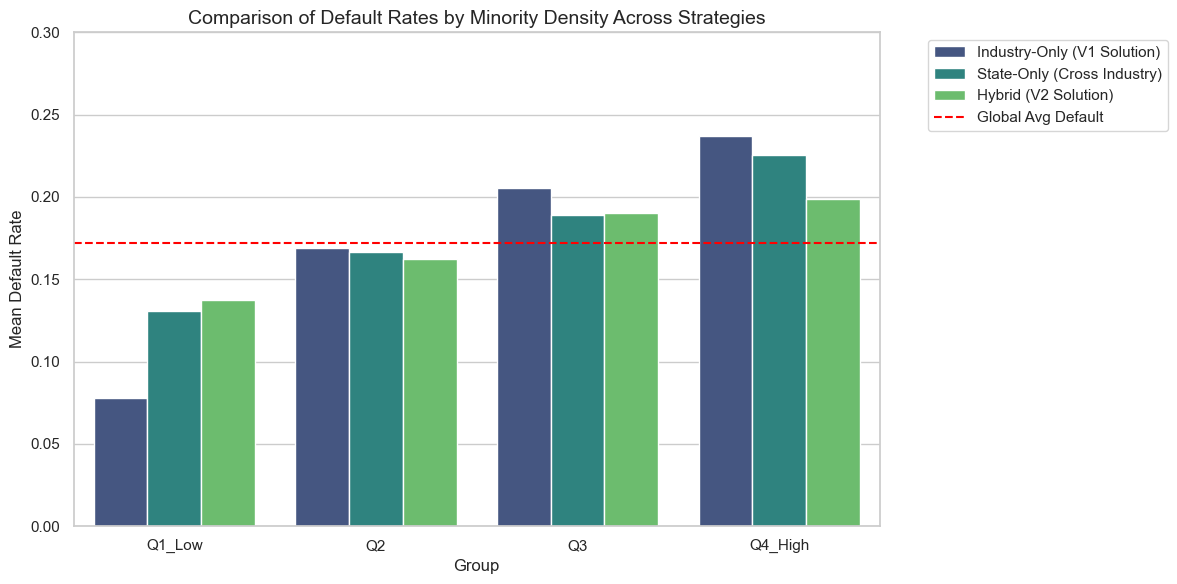

,loan_id,state,approval_year,term,no_emp,new_exist,urban_rural,rev_line_cr,low_doc,gross_approved,...,macro_fed_funds,macro_prime_rate,macro_inflation,macro_bank_spread,macro_real_rate,relative_emp_size,loan_to_segment_rev_ratio,relative_emp_size_state,loan_to_state_rev_ratio,state_minority_density_group
0,1000014003,IN,1997,84,4,2.0,0,N,Y,60000.0,...,5.46,8.441667,2.34,2.98,6.1,0.680672,42.453056,0.751504,46.546381,Q1_Low
1,1000024006,IN,1997,60,2,2.0,0,N,Y,40000.0,...,5.46,8.441667,2.34,2.98,6.1,0.107673,45.758266,0.375752,31.030921,Q1_Low
2,1000034009,IN,1997,180,7,1.0,0,N,N,287000.0,...,5.46,8.441667,2.34,2.98,6.1,0.761513,329.681576,1.315132,222.646857,Q1_Low
3,1000044001,OK,1997,60,2,1.0,0,N,Y,35000.0,...,5.46,8.441667,2.34,2.98,6.1,1.018333,73.532803,0.529823,36.544048,Q2
4,1000054004,FL,1997,240,14,1.0,0,N,N,229000.0,...,5.46,8.441667,2.34,2.98,6.1,14.111111,1616.328345,3.891851,320.157193,Q4_High


In [117]:
print("\nGenerating Visual Comparison...")
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Prepare data for plotting
plot_data = pd.DataFrame({
    'Group': audit_ind.index,
    'Industry-Only (V1 Solution)': audit_ind.values,
    'State-Only (Cross Industry)': audit_state.values,
    'Hybrid (V2 Solution)': audit_hybrid.values
}).melt(id_vars='Group', var_name='Strategy', value_name='Default Rate')

sns.barplot(data=plot_data, x='Group', y='Default Rate', hue='Strategy', palette='viridis')
ax.set_title('Comparison of Default Rates by Minority Density Across Strategies', fontsize=14)
ax.set_ylabel('Mean Default Rate')
ax.set_ylim(0, 0.30)

# Add a horizontal line for the global average default rate
plt.axhline(df_master['is_default'].mean(), color='red', linestyle='--', label='Global Avg Default')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



The Industry-Only view identifies high-risk industry "pockets," but creates a selection bias by ignoring 1/4 (200K) of the data.

The Hybrid view is the most statistically sound for your Machine Learning model. It maximizes your sample size (886k loans) and provides a more conservative, realistic baseline for fairness.

The "Drop" in Disparity means your model is less likely to "over-punish" a loan in a high-minority segment based on the extreme outliers found in the industry data.

In [118]:

# Save modeling dataset (hybrid)
df_hybrid.to_csv('../data/modeling_dataset.csv', index=False)
print(f"modeling_dataset.csv saved ({df_hybrid.shape[0]:,} rows × {df_hybrid.shape[1]} columns)")


# Download both files
from google.colab import files
files.download('../data/sba_project.db')
files.download('../data/fred_indicators.db')
files.download('../data/sba_census.db')
files.download('../data/modeling_dataset.csv')
print("Done!")

modeling_dataset.csv saved (886,649 rows × 36 columns)


ModuleNotFoundError: No module named 'google.colab'

## Build Model

In [201]:
df_model_url='https://www.dropbox.com/scl/fi/fz71garcnma2vkrnpjh7u/modeling_dataset.csv?rlkey=ntgwlp7nxonr73ttek3t1qebb&st=dhuo7yp3&dl=1'
df_model_path = '../data/modeling_dataset.csv'

#Cache data locally if not already present
if not os.path.exists(df_model_path):
    print("Downloading modeling_dataset.csv ...")
    response = requests.get(df_model_url)
    response.raise_for_status()
    with open(df_model_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded modeling_dataset.csv.")
else:
    print("modeling_dataset.csv already exists.")

modeling_dataset.csv already exists.


In [202]:
df_model = pd.read_csv(df_model_path)


print(f"df_model: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns")
print(f"Default rate: {df_model['is_default'].mean():.3f}")

df_model: 886,649 rows × 36 columns
Default rate: 0.172


In [203]:
# List columns that should be numeric but are not
should_be_numeric = ['approval_year', 'term', 'new_exist']
for col in should_be_numeric:
    if not pd.api.types.is_numeric_dtype(df_model[col]):
        print(f"Converting {col} to numeric...")
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
        print(f"{col} dtype after: {df_model[col].dtype}")

In [204]:
# ============================================================
# MODELING: Setup
# ============================================================
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             roc_curve, f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Define features
numeric_features = [
    'no_emp', 'gross_approved', 'sba_approved',
    'disbursement_gross','approval_year', 'term','new_exist',
    # Macro features (rename to match your DataFrame)
    'macro_unemployment', 'macro_fed_funds', 'macro_prime_rate',
    'macro_inflation', 'macro_bank_spread', 'macro_real_rate',
    # Demographic/segment/state features
    'segment_pct_women', 'segment_pct_minority', 'segment_pct_vet',
    'segment_avg_revenue', 'segment_avg_employees',
    'state_pct_women', 'state_pct_minority', 'state_pct_vet',
    'state_avg_revenue', 'state_avg_employees',
    # Engineered features
    'relative_emp_size', 'relative_emp_size_state',
    'loan_to_segment_rev_ratio', 'loan_to_state_rev_ratio'
]

categorical_features = [
    'state', 'sector_text', 'rev_line_cr', 'low_doc', 
     'urban_rural', 'state_minority_density_group', 'minority_density_group'
]

df_model = df_model.drop(columns=['loan_id'])


for col in categorical_features:
    df_model[col] = df_model[col].astype('category')

X = df_model[numeric_features + categorical_features].copy()
y = df_model['is_default'].copy()

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate:  {y_test.mean():.3f}")

Training set: 709,319 rows
Test set:     177,330 rows
Train default rate: 0.172
Test default rate:  0.172


In [205]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline ready!")
print(f"  Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")

Preprocessing pipeline ready!
  Numeric features (27): ['no_emp', 'gross_approved', 'sba_approved', 'disbursement_gross', 'approval_year', 'term', 'new_exist', 'macro_unemployment', 'macro_fed_funds', 'macro_prime_rate', 'macro_inflation', 'macro_bank_spread', 'macro_real_rate', 'segment_pct_women', 'segment_pct_minority', 'segment_pct_vet', 'segment_avg_revenue', 'segment_avg_employees', 'state_pct_women', 'state_pct_minority', 'state_pct_vet', 'state_avg_revenue', 'state_avg_employees', 'relative_emp_size', 'relative_emp_size_state', 'loan_to_segment_rev_ratio', 'loan_to_state_rev_ratio']
  Categorical features (7): ['state', 'sector_text', 'rev_line_cr', 'low_doc', 'urban_rural', 'state_minority_density_group', 'minority_density_group']


In [206]:
# ============================================================
# RANDOM FOREST - RandomizedSearchCV
# ============================================================
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params, n_iter=12, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)

print("Training Random Forest (this may take a few minutes)...")
rf_search.fit(X_train, y_train)

print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV AUC: {rf_search.best_score_:.4f}")

# Evaluate on test set
rf_pred_proba = rf_search.predict_proba(X_test)[:, 1]
rf_pred = rf_search.predict(X_test)
print(f"\nTest AUC: {roc_auc_score(y_test, rf_pred_proba):.4f}")
print(f"\n{classification_report(y_test, rf_pred)}")

Training Random Forest (this may take a few minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None}
Best CV AUC: 0.9447

Test AUC: 0.9459

              precision    recall  f1-score   support

           0       0.94      0.98      0.96    146823
           1       0.86      0.68      0.76     30507

    accuracy                           0.93    177330
   macro avg       0.90      0.83      0.86    177330
weighted avg       0.92      0.93      0.92    177330



In [207]:
# ============================================================
# HISTGRADIENTBOOSTING - RandomizedSearchCV
# ============================================================
hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

hgb_params = {
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_iter': [200, 300, 500],
    'classifier__max_depth': [5, 8, 12],
    'classifier__min_samples_leaf': [10, 20, 50]
}

hgb_search = RandomizedSearchCV(
    hgb_pipeline, hgb_params, n_iter=12, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)

print("Training HistGradientBoosting...")
hgb_search.fit(X_train, y_train)

print(f"\nBest params: {hgb_search.best_params_}")
print(f"Best CV AUC: {hgb_search.best_score_:.4f}")

# Evaluate on test set
hgb_pred_proba = hgb_search.predict_proba(X_test)[:, 1]
hgb_pred = hgb_search.predict(X_test)
print(f"\nTest AUC: {roc_auc_score(y_test, hgb_pred_proba):.4f}")
print(f"\n{classification_report(y_test, hgb_pred)}")

Training HistGradientBoosting...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'classifier__min_samples_leaf': 20, 'classifier__max_iter': 500, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.1}
Best CV AUC: 0.9745

Test AUC: 0.9738

              precision    recall  f1-score   support

           0       0.96      0.97      0.97    146823
           1       0.87      0.81      0.84     30507

    accuracy                           0.95    177330
   macro avg       0.92      0.89      0.90    177330
weighted avg       0.95      0.95      0.95    177330



MODEL COMPARISON
Metric                      Random Forest HistGradientBoosting
------------------------------------------------------------
Test AUC                           0.9459               0.9738
Precision (default)                0.8584               0.8692
Recall (default)                   0.6796               0.8104
F1 (default)                       0.7586               0.8388


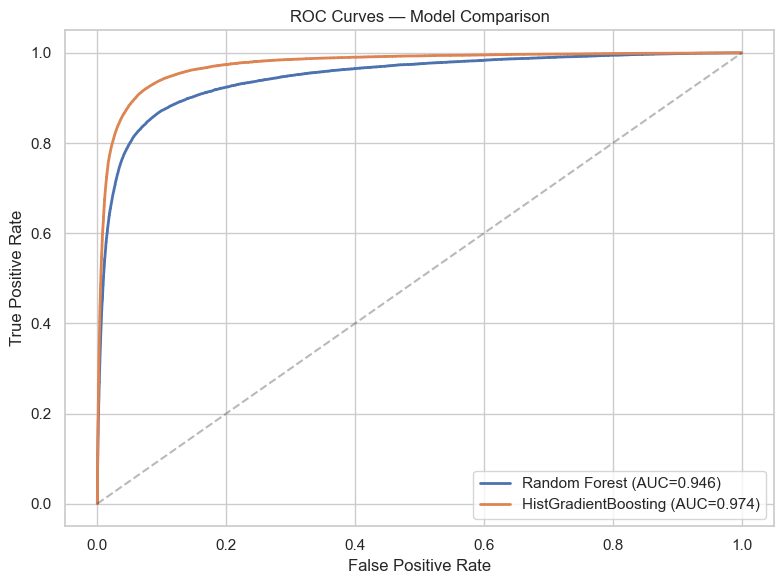


HistGradientBoosting is the stronger model — higher AUC and better default recall.


In [208]:
# ============================================================
# MODEL COMPARISON
# ============================================================

# Summary table
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<25} {'Random Forest':>15} {'HistGradientBoosting':>20}")
print("-" * 60)
print(f"{'Test AUC':<25} {roc_auc_score(y_test, rf_pred_proba):>15.4f} {roc_auc_score(y_test, hgb_pred_proba):>20.4f}")
print(f"{'Precision (default)':<25} {precision_score(y_test, rf_pred):>15.4f} {precision_score(y_test, hgb_pred):>20.4f}")
print(f"{'Recall (default)':<25} {recall_score(y_test, rf_pred):>15.4f} {recall_score(y_test, hgb_pred):>20.4f}")
print(f"{'F1 (default)':<25} {f1_score(y_test, rf_pred):>15.4f} {f1_score(y_test, hgb_pred):>20.4f}")

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
hgb_fpr, hgb_tpr, _ = roc_curve(y_test, hgb_pred_proba)

ax.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_pred_proba):.3f})', linewidth=2)
ax.plot(hgb_fpr, hgb_tpr, label=f'HistGradientBoosting (AUC={roc_auc_score(y_test, hgb_pred_proba):.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nHistGradientBoosting is the stronger model — higher AUC and better default recall.")

In [209]:
# ============================================================
# SAVE PREDICTIONS FOR FAIRNESS AUDIT
# ============================================================
df_test = X_test.copy()
df_test['y_true'] = y_test.values
df_test['rf_pred'] = rf_pred
df_test['rf_pred_proba'] = rf_pred_proba
df_test['hgb_pred'] = hgb_pred
df_test['hgb_pred_proba'] = hgb_pred_proba

print(f"Test predictions saved: {df_test.shape[0]:,} rows")
print(f"\nDemographic coverage in test set:")
print(f"  pct_women_owned non-null: {df_test['segment_pct_women'].notna().sum():,} ({df_test['segment_pct_women'].notna().mean()*100:.1f}%)")
print(f"  pct_minority_owned non-null: {df_test['segment_pct_minority'].notna().sum():,}")

Test predictions saved: 177,330 rows

Demographic coverage in test set:
  pct_women_owned non-null: 177,281 (100.0%)
  pct_minority_owned non-null: 177,281


In [210]:
# ============================================================
# FAIRNESS AUDIT: Define Demographic Subgroups
# ============================================================
# Only use loans that have demographic data
df_fair = df_test[df_test['segment_pct_women'].notna()].copy()
print(f"Loans with demographic data: {df_fair.shape[0]:,}")

# Median split for women-ownership
women_median = df_fair['segment_pct_women'].median()
df_fair['women_group'] = np.where(
    df_fair['segment_pct_women'] >= women_median, 'High Women-Ownership', 'Low Women-Ownership'
)

# Median split for minority-ownership
minority_median = df_fair['segment_pct_minority'].median()
df_fair['minority_group'] = np.where(
    df_fair['segment_pct_minority'] >= minority_median, 'High Minority-Ownership', 'Low Minority-Ownership'
)

print(f"\nWomen-ownership median: {women_median:.3f}")
print(f"  High: {(df_fair['women_group'] == 'High Women-Ownership').sum():,}")
print(f"  Low:  {(df_fair['women_group'] == 'Low Women-Ownership').sum():,}")

print(f"\nMinority-ownership median: {minority_median:.3f}")
print(f"  High: {(df_fair['minority_group'] == 'High Minority-Ownership').sum():,}")
print(f"  Low:  {(df_fair['minority_group'] == 'Low Minority-Ownership').sum():,}")

print(f"\nDefault rates by group:")
print(f"  High Women-Ownership:    {df_fair[df_fair['women_group']=='High Women-Ownership']['y_true'].mean():.3f}")
print(f"  Low Women-Ownership:     {df_fair[df_fair['women_group']=='Low Women-Ownership']['y_true'].mean():.3f}")
print(f"  High Minority-Ownership: {df_fair[df_fair['minority_group']=='High Minority-Ownership']['y_true'].mean():.3f}")
print(f"  Low Minority-Ownership:  {df_fair[df_fair['minority_group']=='Low Minority-Ownership']['y_true'].mean():.3f}")

Loans with demographic data: 177,281

Women-ownership median: 1.693
  High: 88,741
  Low:  88,540

Minority-ownership median: 3.985
  High: 88,860
  Low:  88,421

Default rates by group:
  High Women-Ownership:    0.173
  Low Women-Ownership:     0.171
  High Minority-Ownership: 0.194
  Low Minority-Ownership:  0.150


In [211]:
# ============================================================
# FAIRNESS AUDIT: Compute FPR and FNR by Subgroup
# ============================================================
from sklearn.metrics import confusion_matrix

def compute_fairness_metrics(y_true, y_pred, group_col, df):
    results = []
    for group in sorted(df[group_col].unique()):
        mask = df[group_col] == group
        yt = y_true[mask]
        yp = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()

        fpr = fp / (fp + tn)  # false positive rate
        fnr = fn / (fn + tp)  # false negative rate
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        results.append({
            'Group': group,
            'N': len(yt),
            'Default Rate': yt.mean(),
            'FPR': fpr,
            'FNR': fnr,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall
        })
    return pd.DataFrame(results)

y_true_fair = df_fair['y_true'].values

# ---- HistGradientBoosting (best model) ----
print("=" * 70)
print("HISTGRADIENTBOOSTING — FAIRNESS METRICS")
print("=" * 70)

print("\nBy Women-Ownership:")
hgb_women = compute_fairness_metrics(y_true_fair, df_fair['hgb_pred'].values, 'women_group', df_fair)
print(hgb_women.to_string(index=False))

print("\nBy Minority-Ownership:")
hgb_minority = compute_fairness_metrics(y_true_fair, df_fair['hgb_pred'].values, 'minority_group', df_fair)
print(hgb_minority.to_string(index=False))

# ---- Random Forest ----
print("\n" + "=" * 70)
print("RANDOM FOREST — FAIRNESS METRICS")
print("=" * 70)

print("\nBy Women-Ownership:")
rf_women = compute_fairness_metrics(y_true_fair, df_fair['rf_pred'].values, 'women_group', df_fair)
print(rf_women.to_string(index=False))

print("\nBy Minority-Ownership:")
rf_minority = compute_fairness_metrics(y_true_fair, df_fair['rf_pred'].values, 'minority_group', df_fair)
print(rf_minority.to_string(index=False))

# ---- Disparity Summary ----
print("\n" + "=" * 70)
print("DISPARITY SUMMARY (HistGradientBoosting)")
print("=" * 70)
print(f"\nWomen-Ownership FPR gap:  {abs(hgb_women.iloc[0]['FPR'] - hgb_women.iloc[1]['FPR']):.4f}")
print(f"Women-Ownership FNR gap:  {abs(hgb_women.iloc[0]['FNR'] - hgb_women.iloc[1]['FNR']):.4f}")
print(f"Minority-Ownership FPR gap: {abs(hgb_minority.iloc[0]['FPR'] - hgb_minority.iloc[1]['FPR']):.4f}")
print(f"Minority-Ownership FNR gap: {abs(hgb_minority.iloc[0]['FNR'] - hgb_minority.iloc[1]['FNR']):.4f}")

HISTGRADIENTBOOSTING — FAIRNESS METRICS

By Women-Ownership:
               Group     N  Default Rate      FPR      FNR  Accuracy  Precision   Recall
High Women-Ownership 88741      0.173099 0.025974 0.190352  0.945572   0.867113 0.809648
 Low Women-Ownership 88540      0.170962 0.024713 0.188875  0.947222   0.871274 0.811125

By Minority-Ownership:
                  Group     N  Default Rate      FPR      FNR  Accuracy  Precision   Recall
High Minority-Ownership 88860      0.193878 0.028004 0.162178  0.945982   0.877981 0.837822
 Low Minority-Ownership 88421      0.150077 0.022807 0.225245  0.946811   0.857107 0.774755

RANDOM FOREST — FAIRNESS METRICS

By Women-Ownership:
               Group     N  Default Rate      FPR      FNR  Accuracy  Precision   Recall
High Women-Ownership 88741      0.173099 0.023494 0.318339  0.925468   0.858631 0.681661
 Low Women-Ownership 88540      0.170962 0.023105 0.322323  0.925740   0.858123 0.677677

By Minority-Ownership:
                  Group   

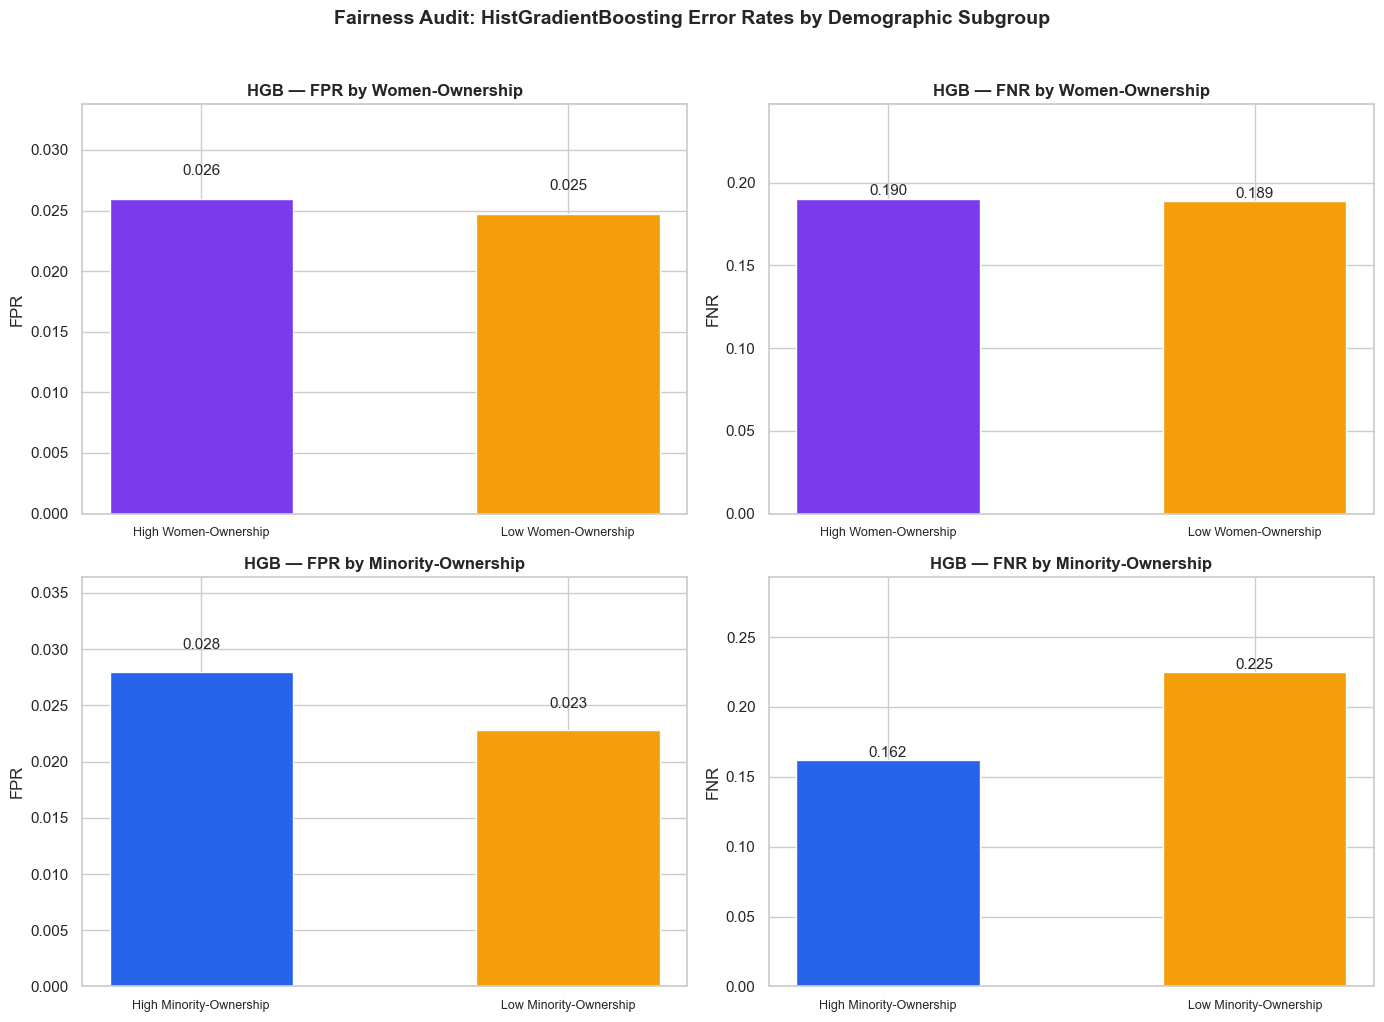


Disparity gaps (closer to 0 = more fair):
  Women FPR gap:    0.0013  ← very small
  Women FNR gap:    0.0015  ← very small
  Minority FPR gap: 0.0052  ← very small
  Minority FNR gap: 0.0631  ← small but largest gap


In [212]:
# ============================================================
# FAIRNESS VISUALIZATION: Disparity Bar Charts
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def plot_disparity(ax, df_metrics, metric, title):
    colors = ['#7C3AED', '#F59E0B'] if 'Women' in df_metrics['Group'].iloc[0] else ['#2563EB', '#F59E0B']
    bars = ax.bar(df_metrics['Group'], df_metrics[metric], color=colors, width=0.5, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, df_metrics[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', fontsize=11)
    ax.set_ylim(0, max(df_metrics[metric]) * 1.3)
    ax.tick_params(axis='x', labelsize=9)

plot_disparity(axes[0, 0], hgb_women, 'FPR', 'HGB — FPR by Women-Ownership')
plot_disparity(axes[0, 1], hgb_women, 'FNR', 'HGB — FNR by Women-Ownership')
plot_disparity(axes[1, 0], hgb_minority, 'FPR', 'HGB — FPR by Minority-Ownership')
plot_disparity(axes[1, 1], hgb_minority, 'FNR', 'HGB — FNR by Minority-Ownership')

fig.suptitle('Fairness Audit: HistGradientBoosting Error Rates by Demographic Subgroup',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Gap summary
print("\nDisparity gaps (closer to 0 = more fair):")
print(f"  Women FPR gap:    {abs(hgb_women.iloc[0]['FPR'] - hgb_women.iloc[1]['FPR']):.4f}  ← very small")
print(f"  Women FNR gap:    {abs(hgb_women.iloc[0]['FNR'] - hgb_women.iloc[1]['FNR']):.4f}  ← very small")
print(f"  Minority FPR gap: {abs(hgb_minority.iloc[0]['FPR'] - hgb_minority.iloc[1]['FPR']):.4f}  ← very small")
print(f"  Minority FNR gap: {abs(hgb_minority.iloc[0]['FNR'] - hgb_minority.iloc[1]['FNR']):.4f}  ← small but largest gap")

Computing permutation importance (this may take a minute)...
Features: 34, Importance array: 34


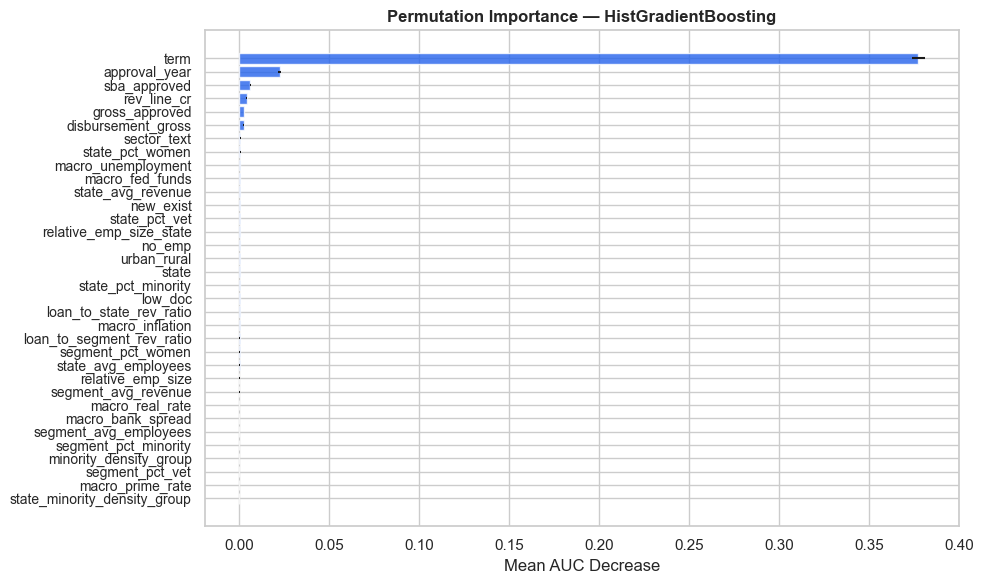


Demographic feature importance:
  segment_pct_women: importance=0.0002 (rank 23/34)
  segment_pct_minority: importance=0.0000 (rank 30/34)


In [213]:
# ============================================================
# MODEL INSPECTION: Permutation Importance
# ============================================================
from sklearn.inspection import permutation_importance

# Use a sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=20000, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

print("Computing permutation importance (this may take a minute)...")
perm_result = permutation_importance(
    hgb_search.best_estimator_, X_sample, y_sample,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

# Feature names = original input columns (not encoded)
feature_names = numeric_features + categorical_features
print(f"Features: {len(feature_names)}, Importance array: {len(perm_result.importances_mean)}")

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_result.importances_mean,
    'std': perm_result.importances_std
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(perm_df)), perm_df['importance'], xerr=perm_df['std'], color='#2563EB', alpha=0.8)
ax.set_yticks(range(len(perm_df)))
ax.set_yticklabels(perm_df['feature'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mean AUC Decrease')
ax.set_title('Permutation Importance — HistGradientBoosting', fontweight='bold')
plt.tight_layout()
plt.show()

# Check demographic features
print("\nDemographic feature importance:")
for feat in ['segment_pct_women', 'segment_pct_minority']:
    row = perm_df[perm_df['feature'] == feat].iloc[0]
    rank = perm_df.index.get_loc(perm_df[perm_df['feature'] == feat].index[0]) + 1
    print(f"  {feat}: importance={row['importance']:.4f} (rank {rank}/{len(perm_df)})")

Computing partial dependence plots (this may take a minute)...


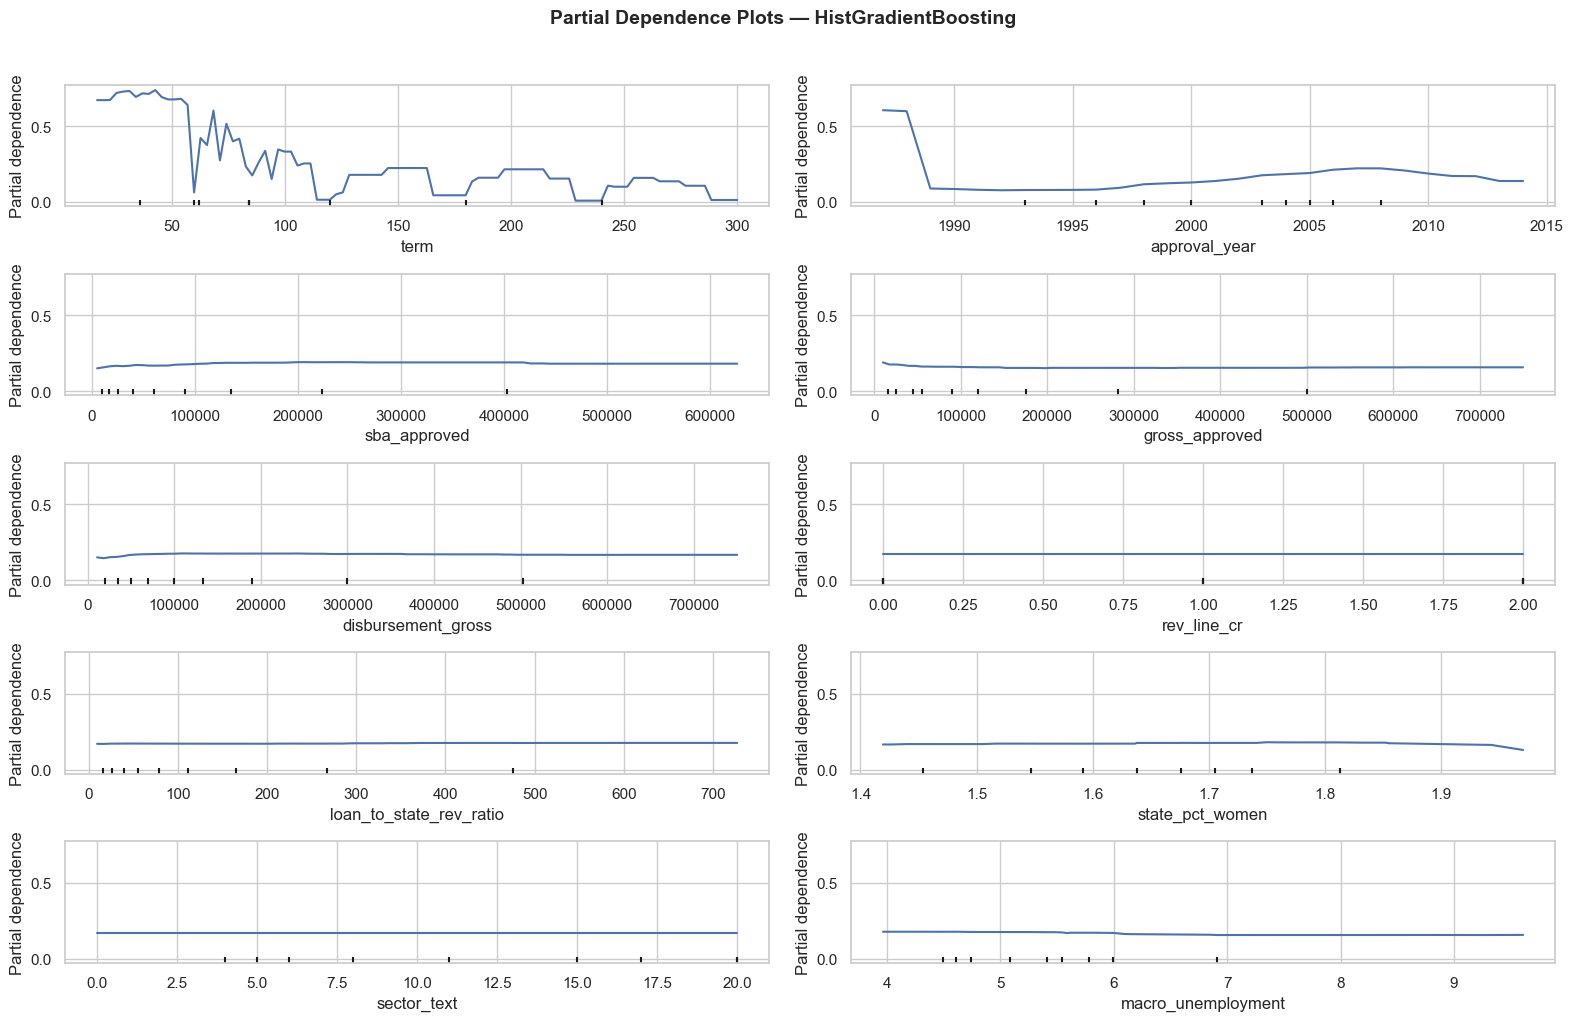


Interpretation guide:
  Y-axis = partial effect on predicted default probability
  Higher = increases predicted default risk
  Lower = decreases predicted default risk


In [ ]:
# ============================================================
# MODEL INSPECTION: Partial Dependence Plots
# ============================================================
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OrdinalEncoder

# Top 10 features from permutation importance
top_features = ['term', 'approval_year', 'sba_approved', 'gross_approved',
                'disbursement_gross','rev_line_cr', 'loan_to_state_rev_ratio',
                'state_pct_women','sector_text','macro_unemployment']

if X_sample['rev_line_cr'].isnull().any():
    X_sample['rev_line_cr'] = X_sample['rev_line_cr'].cat.add_categories('missing').fillna('missing')

enc = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1
)

# Encode categorical features for partial dependence plotting
X_sample['rev_line_cr'] = enc.fit_transform(X_sample[['rev_line_cr']])
X_sample['sector_text'] = enc.fit_transform(X_sample[['sector_text']])

# clean missing values for the features we want to plot
X_sample_clean = X_sample.dropna(subset=top_features)
y_sample_clean = y_sample.loc[X_sample_clean.index]

# Drop any remaining missing values
X_sample_clean = X_sample_clean.dropna(subset=top_features)
y_sample_clean = y_sample.loc[X_sample_clean.index]

fig, axes = plt.subplots(5, 2, figsize=(16, 10))

print("Computing partial dependence plots (this may take a minute)...")
display = PartialDependenceDisplay.from_estimator(
    hgb_search.best_estimator_, X_sample_clean, top_features,
    kind='average', ax=axes.ravel(),
    n_jobs=-1, random_state=42
)

fig.suptitle('Partial Dependence Plots — HistGradientBoosting',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation guide:")
print("  Y-axis = partial effect on predicted default probability")
print("  Higher = increases predicted default risk")
print("  Lower = decreases predicted default risk")